In [2]:
# import packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

## Function definitions:
# def grp3(row): group labels to create a priority order for overlapping dummy variables
# grp4(row): group labels to create a priority order for overlapping dummy variables
# grp_label(row): converts lowercase and underscored variable names to presentable category names on visualizations
# fmt_p(p) — formats a p-value for display, showing "< 0.001" for very small values and three decimal places otherwise.
# star(p) — returns significance-star notation for a p-value (***/**/*/† for p < 0.001/0.01/0.05/0.10, or blank if not significant at the 0.10 level).

In [3]:
# load files

top_100_tracks = pd.read_csv("data/top_100_tracks.csv",
                dtype= {"music_id":str})

top_100_df = pd.read_csv("data/top_100_df.csv",
                dtype= {"music_id":str})

top_with_politics = pd.read_csv("data/top_with_politics.csv",
                dtype= {"music_id":str})

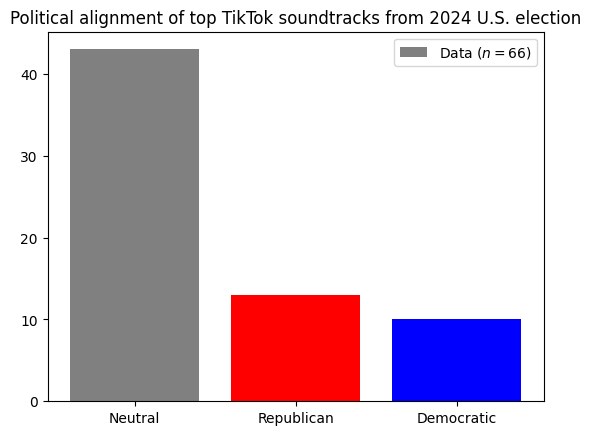

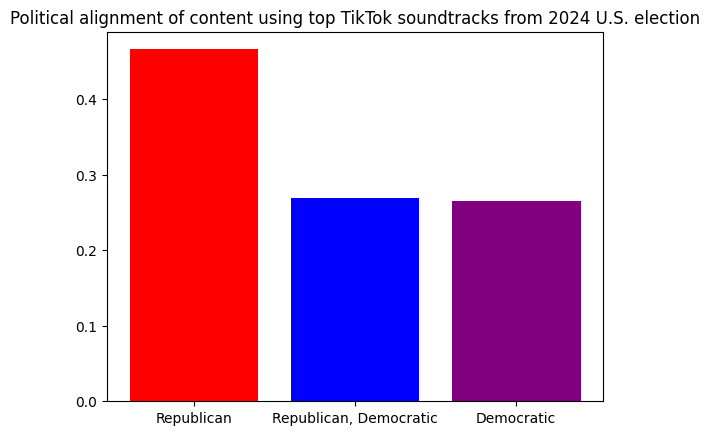

In [4]:
# bar chart depicting political alignment of top tiktok soundtracks from 2024 U.S. election
plt.bar(top_100_tracks.track_category.value_counts().index, 
        top_100_tracks.track_category.value_counts().values, 
        color = ["gray", "red", "blue"])
plt.title("Political alignment of top TikTok soundtracks from 2024 U.S. election")
plt.legend([f'Data ($n = {len(top_100_tracks)}$)'])
plt.savefig("output/figure1.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# bar chart depicting political alignment of content using top tiktok soundtracks from 2024 election
plt.bar(top_100_df.content_category.value_counts().index, 
        top_100_df.content_category.value_counts(normalize=True).values, 
        color = ["red", "blue", "purple"])
plt.title("Political alignment of content using top TikTok soundtracks from 2024 U.S. election")
plt.savefig("output/figure2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

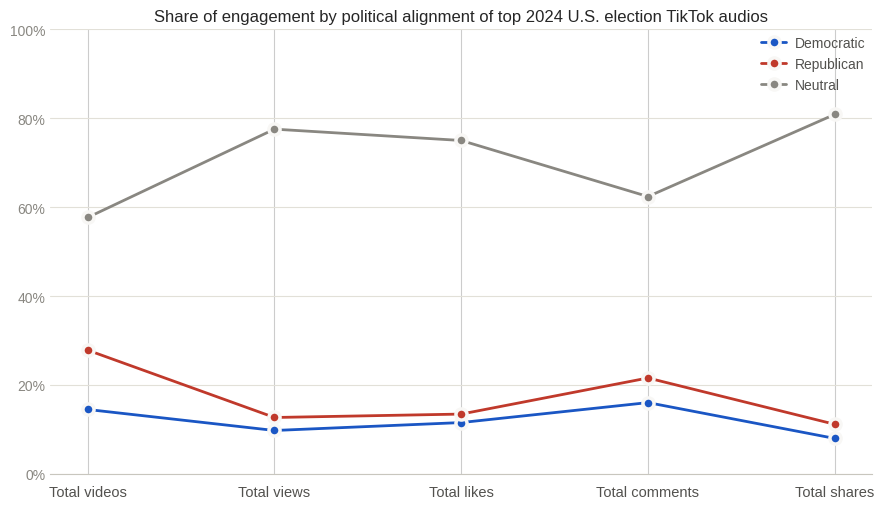

In [44]:

# --- Line graph: share of engagement by political track category ---
# Each metric column sums Democratic + Republican + Neutral = 100%

# Raw sums from top_100_df.groupby("track_category")
sums = top_100_df.groupby("track_category").agg(
    videos=("music_id", "count"),
    views=("view_count", "sum"),
    likes=("like_count", "sum"),
    comments=("comment_count", "sum"),
    shares=("share_count", "sum"),
)

# Convert each column to percentage of its total
pct = sums.div(sums.sum(axis=0), axis=1) * 100

metrics     = ["Total videos", "Total views", "Total likes", "Total comments", "Total shares"]
col_keys    = ["videos", "views", "likes", "comments", "shares"]
categories  = ["Democratic", "Republican", "Neutral"]
colors      = {"Democratic": "#1a56c4", "Republican": "#c0392b", "Neutral": "#898781"}

x = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Gridlines
ax.yaxis.grid(True, color="#e2e0d8", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for cat in categories:
    y = [pct.loc[cat, k] for k in col_keys]
    ax.plot(
        x, y,
        color=colors[cat],
        linewidth=2,
        marker="o",
        markersize=8,
        markeredgewidth=2.5,
        markeredgecolor="#f8f7f5",   # surface ring
        label=cat,
        zorder=3,
    )

# Axes formatting
ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=10.5, color="#52514e")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(axis="y", labelsize=10, colors="#898781", length=0)
ax.tick_params(axis="x", length=0, pad=8)

# Spine cleanup
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#c8c6be")
ax.spines["bottom"].set_linewidth(0.8)

# Legend
legend = ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right",
    labelcolor="#52514e",
    handlelength=1.8,
    handletextpad=0.6,
    borderpad=0,
)

# Title
ax.set_title(
    "Share of engagement by political alignment of top 2024 U.S. election TikTok audios"
)

plt.tight_layout()
plt.savefig("output/figure3.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


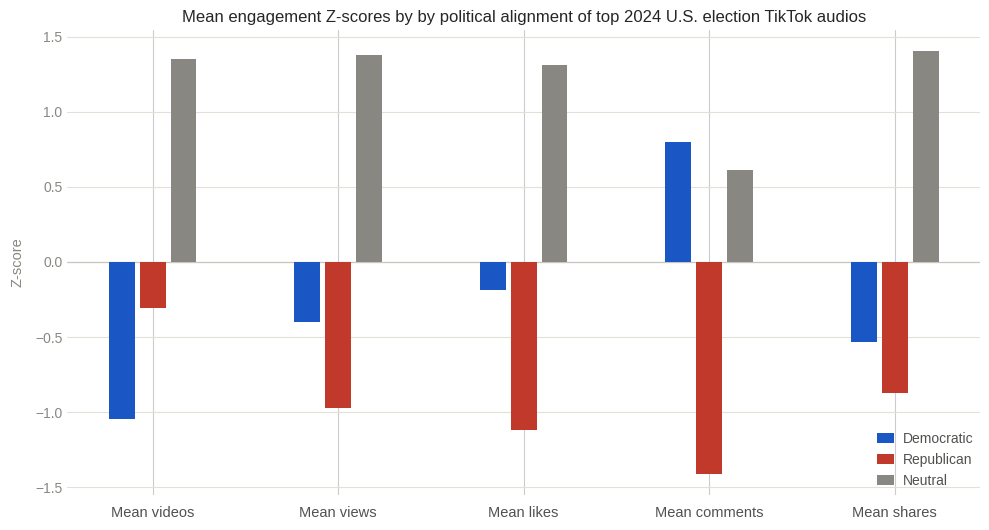

In [45]:

# --- Grouped bar chart: Z-scores of mean engagement by political track category ---

# Compute means per category
means = top_100_df.groupby("track_category").agg(
    videos=("music_id",     "count"),
    views=("view_count",    "mean"),
    likes=("like_count",    "mean"),
    comments=("comment_count", "mean"),
    shares=("share_count",  "mean"),
)

# Z-score each column across the 3 categories (mean=0, std=1 per metric)
z = means.apply(stats.zscore, axis=0)

metrics  = ["Mean videos", "Mean views", "Mean likes", "Mean comments", "Mean shares"]
col_keys = ["videos", "views", "likes", "comments", "shares"]
cats     = ["Democratic", "Republican", "Neutral"]
colors   = {"Democratic": "#1a56c4", "Republican": "#c0392b", "Neutral": "#898781"}

n_metrics = len(metrics)
n_cats    = len(cats)
bar_w     = 0.12
group_gap = 0.72          # distance between group centres

x_centres = [i * group_gap for i in range(n_metrics)]
offsets   = [-bar_w, 0, bar_w]   # one offset per category

fig, ax = plt.subplots(figsize=(10, 5.4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Horizontal gridlines
ax.yaxis.grid(True, color="#e2e0d8", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Zero baseline
ax.axhline(0, color="#c8c6be", linewidth=0.9, zorder=1)

for cat, offset in zip(cats, offsets):
    bar_x = [c + offset for c in x_centres]
    bar_h = [z.loc[cat, k] for k in col_keys]
    ax.bar(
        bar_x, bar_h,
        width=bar_w - 0.02,       # 2 px surface gap between adjacent bars
        color=colors[cat],
        label=cat,
        zorder=2,
        clip_on=False,
    )

# X-axis ticks centred on each group
ax.set_xticks(x_centres)
ax.set_xticklabels(metrics, fontsize=10.5, color="#52514e")
ax.tick_params(axis="x", length=0, pad=8)
ax.tick_params(axis="y", labelsize=10, colors="#898781", length=0)

ax.set_ylabel("Z-score", fontsize=10.5, color="#898781", labelpad=8)

# Spine cleanup
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right",
    labelcolor="#52514e",
    handlelength=1.2,
    handletextpad=0.6,
    borderpad=0,
)

ax.set_title(
    "Mean engagement Z-scores by by political alignment of top 2024 U.S. election TikTok audios"
)

plt.tight_layout()
plt.savefig("output/figure4.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


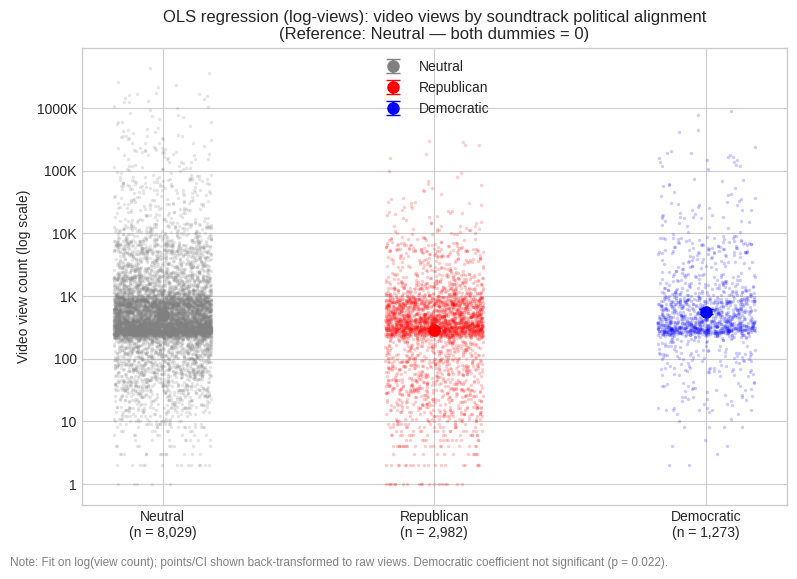

In [46]:
# TRYING WITH LOG!

# ── Scatterplot: observed points + OLS fitted means + 95% CI (log-space fit) ──
# Each group jitter-plotted; fitted value = intercept (± coefficient), fit on log(views)
rng = np.random.default_rng(42)
COLORS = {"Neutral": "gray", "Republican": "red", "Democratic": "blue"}
ORDER  = ["Neutral", "Republican", "Democratic"]

def grp_label(row):
    if row["is_track_republican"] == 1: return "Republican"
    if row["is_track_democratic"]  == 1: return "Democratic"
    return "Neutral"

reg_df = top_with_politics[
    ["view_count", "is_track_republican", "is_track_democratic"]
].dropna().copy()
reg_df["group"] = reg_df.apply(grp_label, axis=1)

# ─── CHANGED: drop non-positive views (log undefined at 0) and add log_views ───
reg_df = reg_df[reg_df["view_count"] > 0].copy()
reg_df["log_views"] = np.log(reg_df["view_count"])

# ─── CHANGED: refit OLS on log_views instead of raw view_count ───
model = sm.OLS(
    reg_df["log_views"],
    sm.add_constant(reg_df[["is_track_republican", "is_track_democratic"]]),
).fit()

# fitted values are now log-scale means per group
fitted_log = {
    "Neutral":    model.params["const"],
    "Republican": model.params["const"] + model.params["is_track_republican"],
    "Democratic": model.params["const"] + model.params["is_track_democratic"],
}

# ─── CHANGED: compute SE/CI on log_views, not raw view_count ───
grp_stats = (
    reg_df.groupby("group")["log_views"]
    .agg(count="count", std="std")
    .assign(se=lambda d: d["std"] / np.sqrt(d["count"]))
)
grp_stats["fitted_log"] = [fitted_log[g] for g in grp_stats.index]
grp_stats["ci_lo_log"]  = grp_stats["fitted_log"] - 1.96 * grp_stats["se"]
grp_stats["ci_hi_log"]  = grp_stats["fitted_log"] + 1.96 * grp_stats["se"]

# ─── CHANGED: exponentiate fitted values and CI bounds back to raw-view scale
#              so the plotted points/error bars are interpretable as view counts ───
grp_stats["fitted"] = np.exp(grp_stats["fitted_log"])
grp_stats["ci_lo"]  = np.exp(grp_stats["ci_lo_log"])
grp_stats["ci_hi"]  = np.exp(grp_stats["ci_hi_log"])

# ─── CHANGED: no need to cap at 99th percentile for display — log scale already
#              compresses the tail, so we keep the full (positive) distribution ───
reg_df_disp = reg_df.copy()

x_pos  = {g: i for i, g in enumerate(ORDER)}
jitter = 0.18
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5.6))

for group in ORDER:
    sub = reg_df_disp[reg_df_disp["group"] == group]["view_count"].values
    xj  = rng.uniform(x_pos[group] - jitter, x_pos[group] + jitter, size=len(sub))
    ax.scatter(xj, sub, s=6, alpha=0.2, color=COLORS[group], linewidths=0)

for group in ORDER:
    xi  = x_pos[group]
    ax.errorbar(
        xi, grp_stats.loc[group, "fitted"],
        yerr=[[grp_stats.loc[group, "fitted"] - grp_stats.loc[group, "ci_lo"]],
              [grp_stats.loc[group, "ci_hi"]  - grp_stats.loc[group, "fitted"]]],
        fmt="o", color=COLORS[group], markersize=8, capsize=5, linewidth=1.5,
        label=group,
    )

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels(
    [f"{g}\n(n = {grp_stats.loc[g, 'count']:,})" for g in ORDER]
)

# ─── CHANGED: log-scale y-axis instead of linear with manual K-formatting ───
ax.set_yscale("log")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1_000:.0f}K" if v >= 1000 else f"{v:.0f}")
)

ax.set_ylabel("Video view count (log scale)")
ax.set_title(
    "OLS regression (log-views): video views by soundtrack political alignment\n"
    "(Reference: Neutral — both dummies = 0)"
)
ax.legend(frameon=False)

# ─── CHANGED: note reflects log-space fit; removed capping note, added p-value
#              pulled dynamically from the refit model instead of hardcoded ───
p_dem = model.pvalues["is_track_democratic"]
fig.text(
    0.01, -0.02,
    f"Note: Fit on log(view count); points/CI shown back-transformed to raw views. "
    f"Democratic coefficient not significant (p = {p_dem:.3f}).",
    fontsize=8.5, color="gray",
)
plt.tight_layout()
plt.savefig("output/figure5.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [47]:

# ── Results table for log(views) ~ is_track_republican + is_track_democratic ──
# Uses the `model` refitted on log_views in the cell above.
# Reference category (both dummies = 0): Neutral soundtrack

params = model.params
bse    = model.bse
tvals  = model.tvalues
pvals  = model.pvalues
ci     = model.conf_int()

def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

def star(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"
    return ""

labels = {
    "const":               "Intercept (Neutral soundtrack)",
    "is_track_republican": "Republican soundtrack",
    "is_track_democratic": "Democratic soundtrack",
}

rows = []
for key, label in labels.items():
    rows.append({
        "Variable":  label,
        "Coef.":     f"{params[key]:.4f}",
        "Std. Err.": f"{bse[key]:.4f}",
        "t":         f"{tvals[key]:.3f}",
        "p":         fmt_p(pvals[key]),
        "":          star(pvals[key]),
        "95% CI":    f"[{ci.loc[key,0]:.4f}, {ci.loc[key,1]:.4f}]",
    })

footer = {
    "Variable":  f"n = {int(model.nobs):,}   R² = {model.rsquared:.4f}   Adj. R² = {model.rsquared_adj:.4f}   "
                 f"F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.3f}   p {fmt_p(model.f_pvalue)}",
    "Coef.": "", "Std. Err.": "", "t": "", "p": "", "": "", "95% CI": "",
}

full_table = pd.DataFrame(rows + [footer])

styled = (
    full_table.style
    .hide(axis="index")
    .set_caption("OLS: log(view count) ~ soundtrack political alignment  (ref: Neutral)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "12.5px"), ("font-weight", "600"),
                   ("text-align", "left"), ("padding-bottom", "4px")]},
        {"selector": "thead th",
         "props": [("border-top", "2px solid #111"), ("border-bottom", "1px solid #888"),
                   ("padding", "4px 10px"), ("font-size", "11.5px"),
                   ("text-align", "right"), ("background", "none")]},
        {"selector": "thead th:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody td",
         "props": [("padding", "3px 10px"), ("font-size", "12px"),
                   ("text-align", "right"), ("border", "none")]},
        {"selector": "tbody td:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody tr:last-child td",
         "props": [("border-top", "1px solid #888"), ("color", "#555"),
                   ("font-size", "11px"), ("padding-top", "5px")]},
        {"selector": "",
         "props": [("border-collapse", "collapse"),
                   ("font-family", 'system-ui, -apple-system, sans-serif')]},
    ])
)

print("Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10")
display(styled)

Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


Variable,Coef.,Std. Err.,t,p,,95% CI
Intercept (Neutral soundtrack),6.2165,0.0183,339.241,< 0.001,***,"[6.1806, 6.2524]"
Republican soundtrack,-0.5524,0.0352,-15.688,< 0.001,***,"[-0.6214, -0.4834]"
Democratic soundtrack,0.1132,0.0495,2.285,0.022,*,"[0.0161, 0.2103]"
"n = 12,284 R² = 0.0219 Adj. R² = 0.0218 F(2, 12281) = 137.666 p < 0.001",,,,,,


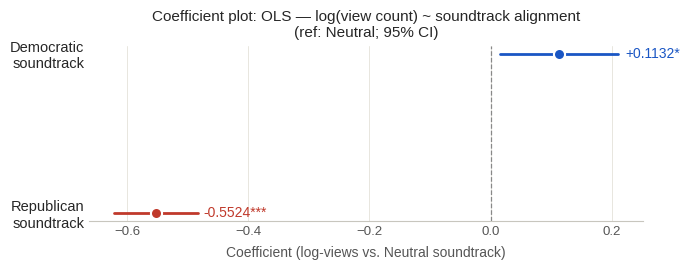

In [48]:

# ── Coefficient plot: log(views) ~ is_track_republican + is_track_democratic ──
# (Intercept omitted; reference = Neutral soundtrack)

_labels2 = {
    "is_track_republican": "Republican\nsoundtrack",
    "is_track_democratic": "Democratic\nsoundtrack",
}
_keys2   = list(_labels2.keys())
_names2  = [_labels2[k] for k in _keys2]
_coefs2  = [model.params[k]  for k in _keys2]
_lo2     = [model.conf_int().loc[k, 0] for k in _keys2]
_hi2     = [model.conf_int().loc[k, 1] for k in _keys2]
_pvals2  = [model.pvalues[k] for k in _keys2]

_colors2 = ["#c0392b", "#1a56c4"]
_y2      = range(len(_keys2))

fig, ax = plt.subplots(figsize=(7, 2.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvline(0, color="#888", linewidth=0.9, linestyle="--", zorder=1)

for i, (coef, lo, hi, col, p) in enumerate(zip(_coefs2, _lo2, _hi2, _colors2, _pvals2)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=2, solid_capstyle="round", zorder=2)
    ax.plot(coef, i, "o", color=col, markersize=8, zorder=3,
            markeredgecolor="white", markeredgewidth=1.5)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else ""
    _span = max(abs(hi - lo), 0.01)
    ax.text(hi + _span * 0.06, i, f"{coef:+.4f}{sig}",
            va="center", ha="left", fontsize=10, color=col)

ax.set_yticks(list(_y2))
ax.set_yticklabels(_names2, fontsize=10.5)
ax.tick_params(axis="x", labelsize=9.5, colors="#555", length=0)
ax.tick_params(axis="y", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#c8c6be")
ax.spines["bottom"].set_linewidth(0.8)

ax.set_xlabel("Coefficient (log-views vs. Neutral soundtrack)", fontsize=10, color="#555", labelpad=6)
ax.set_title("Coefficient plot: OLS — log(view count) ~ soundtrack alignment\n(ref: Neutral; 95% CI)", fontsize=11)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color="#e8e6de", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("output/figure6.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


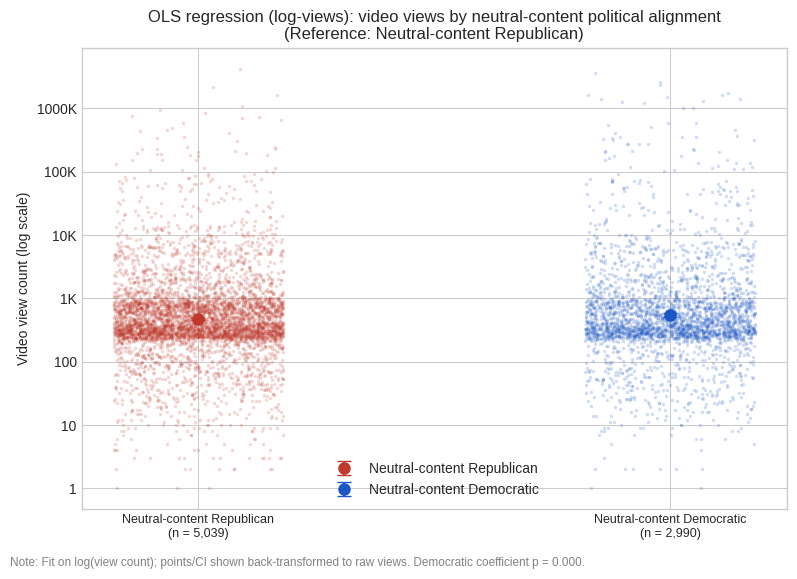

In [49]:

# ── Model 3: log(views) ~ is_neutral_content_democratic ──────────────────────
# Reference category (is_neutral_content_republican = 1, is_neutral_content_democratic = 0):
#   videos on a Republican-leaning neutral-content track
# k-1 dummies: drop is_neutral_content_republican (the reference)

rng = np.random.default_rng(42)

reg_df3 = top_with_politics[
    ["view_count", "is_neutral_content_republican", "is_neutral_content_democratic"]
].dropna().copy()
reg_df3 = reg_df3[reg_df3["view_count"] > 0].copy()
reg_df3["log_views"] = np.log(reg_df3["view_count"])

# Keep only rows that belong to exactly one of the two content groups
reg_df3 = reg_df3[
    (reg_df3["is_neutral_content_republican"] == 1) |
    (reg_df3["is_neutral_content_democratic"] == 1)
].copy()

# k-1 dummies: reference = is_neutral_content_republican
X3 = sm.add_constant(reg_df3[["is_neutral_content_democratic"]])
model3 = sm.OLS(reg_df3["log_views"], X3).fit()

# ── Group labels ─────────────────────────────────────────────────────────────
def grp3(row):
    if row["is_neutral_content_democratic"] == 1: return "Neutral-content Democratic"
    return "Neutral-content Republican"

reg_df3["group"] = reg_df3.apply(grp3, axis=1)

ORDER3  = ["Neutral-content Republican", "Neutral-content Democratic"]
COLORS3 = {"Neutral-content Republican": "#c0392b", "Neutral-content Democratic": "#1a56c4"}

fitted_log3 = {
    "Neutral-content Republican": model3.params["const"],
    "Neutral-content Democratic": model3.params["const"] + model3.params["is_neutral_content_democratic"],
}

grp_stats3 = (
    reg_df3.groupby("group")["log_views"]
    .agg(count="count", std="std")
    .assign(se=lambda d: d["std"] / np.sqrt(d["count"]))
)
grp_stats3["fitted_log"] = [fitted_log3[g] for g in grp_stats3.index]
grp_stats3["ci_lo_log"]  = grp_stats3["fitted_log"] - 1.96 * grp_stats3["se"]
grp_stats3["ci_hi_log"]  = grp_stats3["fitted_log"] + 1.96 * grp_stats3["se"]
grp_stats3["fitted"] = np.exp(grp_stats3["fitted_log"])
grp_stats3["ci_lo"]  = np.exp(grp_stats3["ci_lo_log"])
grp_stats3["ci_hi"]  = np.exp(grp_stats3["ci_hi_log"])

x_pos3  = {g: i for i, g in enumerate(ORDER3)}
jitter  = 0.18

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5.6))

for group in ORDER3:
    sub = reg_df3[reg_df3["group"] == group]["view_count"].values
    xj  = rng.uniform(x_pos3[group] - jitter, x_pos3[group] + jitter, size=len(sub))
    ax.scatter(xj, sub, s=6, alpha=0.2, color=COLORS3[group], linewidths=0)

for group in ORDER3:
    xi = x_pos3[group]
    ax.errorbar(
        xi, grp_stats3.loc[group, "fitted"],
        yerr=[[grp_stats3.loc[group, "fitted"] - grp_stats3.loc[group, "ci_lo"]],
              [grp_stats3.loc[group, "ci_hi"]  - grp_stats3.loc[group, "fitted"]]],
        fmt="o", color=COLORS3[group], markersize=8, capsize=5, linewidth=1.5,
        label=group,
    )

ax.set_xticks(list(x_pos3.values()))
ax.set_xticklabels(
    [f"{g}\n(n = {grp_stats3.loc[g, 'count']:,})" for g in ORDER3],
    fontsize=9,
)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1_000:.0f}K" if v >= 1000 else f"{v:.0f}")
)
ax.set_ylabel("Video view count (log scale)")
ax.set_title(
    "OLS regression (log-views): video views by neutral-content political alignment\n"
    "(Reference: Neutral-content Republican)"
)
ax.legend(frameon=False)

p_dem3 = model3.pvalues["is_neutral_content_democratic"]
fig.text(
    0.01, -0.02,
    f"Note: Fit on log(view count); points/CI shown back-transformed to raw views. "
    f"Democratic coefficient p = {p_dem3:.3f}.",
    fontsize=8.5, color="gray",
)
plt.tight_layout()
plt.savefig("output/figure7.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [50]:

# ── Results table: log(views) ~ is_neutral_content_democratic ─────────────────
# Reference: is_neutral_content_republican  (k-1 dummies)

params3 = model3.params
bse3    = model3.bse
tvals3  = model3.tvalues
pvals3  = model3.pvalues
ci3     = model3.conf_int()

labels3 = {
    "const":                       "Intercept (Neutral-content Republican)",
    "is_neutral_content_democratic": "Neutral-content Democratic",
}

rows3 = []
for key, label in labels3.items():
    rows3.append({
        "Variable":  label,
        "Coef.":     f"{params3[key]:.4f}",
        "Std. Err.": f"{bse3[key]:.4f}",
        "t":         f"{tvals3[key]:.3f}",
        "p":         fmt_p(pvals3[key]),
        "":          star(pvals3[key]),
        "95% CI":    f"[{ci3.loc[key,0]:.4f}, {ci3.loc[key,1]:.4f}]",
    })

footer3 = {
    "Variable":  f"n = {int(model3.nobs):,}   R² = {model3.rsquared:.4f}   Adj. R² = {model3.rsquared_adj:.4f}   "
                 f"F({int(model3.df_model)}, {int(model3.df_resid)}) = {model3.fvalue:.3f}   p {fmt_p(model3.f_pvalue)}",
    "Coef.": "", "Std. Err.": "", "t": "", "p": "", "": "", "95% CI": "",
}

full3 = pd.DataFrame(rows3 + [footer3])

styled3 = (
    full3.style
    .hide(axis="index")
    .set_caption("OLS: log(view count) ~ neutral-content political alignment  (ref: Neutral-content Republican)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "12.5px"), ("font-weight", "600"),
                   ("text-align", "left"), ("padding-bottom", "4px")]},
        {"selector": "thead th",
         "props": [("border-top", "2px solid #111"), ("border-bottom", "1px solid #888"),
                   ("padding", "4px 10px"), ("font-size", "11.5px"),
                   ("text-align", "right"), ("background", "none")]},
        {"selector": "thead th:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody td",
         "props": [("padding", "3px 10px"), ("font-size", "12px"),
                   ("text-align", "right"), ("border", "none")]},
        {"selector": "tbody td:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody tr:last-child td",
         "props": [("border-top", "1px solid #888"), ("color", "#555"),
                   ("font-size", "11px"), ("padding-top", "5px")]},
        {"selector": "",
         "props": [("border-collapse", "collapse"),
                   ("font-family", 'system-ui, -apple-system, sans-serif')]},
    ])
)

print("Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10")
display(styled3)


Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


Variable,Coef.,Std. Err.,t,p,,95% CI
Intercept (Neutral-content Republican),6.1660,0.0227,271.515,< 0.001,***,"[6.1215, 6.2105]"
Neutral-content Democratic,0.1356,0.0372,3.643,< 0.001,***,"[0.0626, 0.2085]"
"n = 8,029 R² = 0.0017 Adj. R² = 0.0015 F(1, 8027) = 13.271 p < 0.001",,,,,,


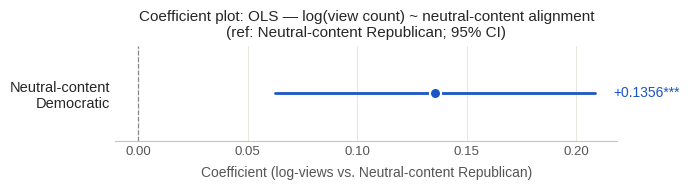

In [51]:

# ── Coefficient plot: log(views) ~ is_neutral_content_democratic ──────────────
# (Intercept omitted; reference = Neutral-content Republican)

_labels3 = {
    "is_neutral_content_democratic": "Neutral-content\nDemocratic",
}
_keys3   = list(_labels3.keys())
_names3  = [_labels3[k] for k in _keys3]
_coefs3  = [model3.params[k]  for k in _keys3]
_lo3     = [model3.conf_int().loc[k, 0] for k in _keys3]
_hi3     = [model3.conf_int().loc[k, 1] for k in _keys3]
_pvals3  = [model3.pvalues[k] for k in _keys3]

_colors3 = ["#1a56c4"]
_y3      = range(len(_keys3))

fig, ax = plt.subplots(figsize=(7, 2.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvline(0, color="#888", linewidth=0.9, linestyle="--", zorder=1)

for i, (coef, lo, hi, col, p) in enumerate(zip(_coefs3, _lo3, _hi3, _colors3, _pvals3)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=2, solid_capstyle="round", zorder=2)
    ax.plot(coef, i, "o", color=col, markersize=8, zorder=3,
            markeredgecolor="white", markeredgewidth=1.5)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else ""
    _span = max(abs(hi - lo), 0.01)
    ax.text(hi + _span * 0.06, i, f"{coef:+.4f}{sig}",
            va="center", ha="left", fontsize=10, color=col)

ax.set_yticks(list(_y3))
ax.set_yticklabels(_names3, fontsize=10.5)
ax.tick_params(axis="x", labelsize=9.5, colors="#555", length=0)
ax.tick_params(axis="y", length=0)
ax.set_ylim(-0.6, 0.6)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#c8c6be")
ax.spines["bottom"].set_linewidth(0.8)

ax.set_xlabel("Coefficient (log-views vs. Neutral-content Republican)", fontsize=10, color="#555", labelpad=6)
ax.set_title("Coefficient plot: OLS — log(view count) ~ neutral-content alignment\n(ref: Neutral-content Republican; 95% CI)", fontsize=11)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color="#e8e6de", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("output/figure8.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


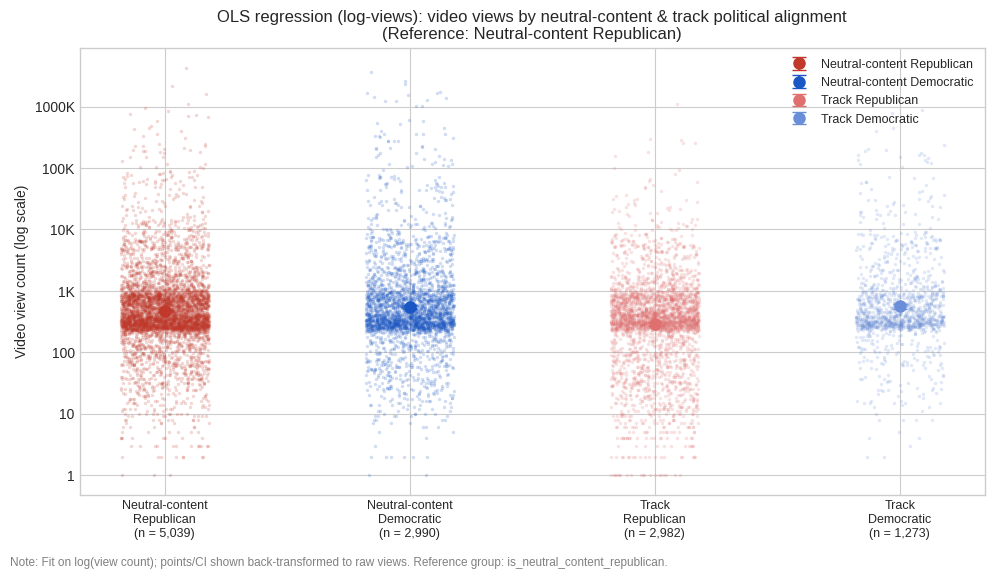

In [52]:

# ── Model 4: log(views) ~ is_neutral_content_democratic + is_track_democratic + is_track_republican ──
# Reference: is_neutral_content_republican  (k-1 dummies, 3 dummies included)
# Rows used: union of all four indicator groups

rng = np.random.default_rng(42)

reg_df4 = top_with_politics[
    ["view_count",
     "is_neutral_content_republican", "is_neutral_content_democratic",
     "is_track_democratic", "is_track_republican"]
].dropna().copy()
reg_df4 = reg_df4[reg_df4["view_count"] > 0].copy()
reg_df4["log_views"] = np.log(reg_df4["view_count"])

# Keep rows belonging to at least one of the four groups
reg_df4 = reg_df4[
    (reg_df4["is_neutral_content_republican"] == 1) |
    (reg_df4["is_neutral_content_democratic"]  == 1) |
    (reg_df4["is_track_democratic"]            == 1) |
    (reg_df4["is_track_republican"]            == 1)
].copy()

# k-1 dummies: reference = is_neutral_content_republican
X4 = sm.add_constant(
    reg_df4[["is_neutral_content_democratic", "is_track_democratic", "is_track_republican"]]
)
model4 = sm.OLS(reg_df4["log_views"], X4).fit()

def grp4(row):
    if row["is_neutral_content_republican"] == 1: return "Neutral-content\nRepublican"
    if row["is_neutral_content_democratic"]  == 1: return "Neutral-content\nDemocratic"
    if row["is_track_republican"]            == 1: return "Track\nRepublican"
    if row["is_track_democratic"]            == 1: return "Track\nDemocratic"
    return "Other"

reg_df4["group"] = reg_df4.apply(grp4, axis=1)

ORDER4 = [
    "Neutral-content\nRepublican",
    "Neutral-content\nDemocratic",
    "Track\nRepublican",
    "Track\nDemocratic",
]
COLORS4 = {
    "Neutral-content\nRepublican": "#c0392b",
    "Neutral-content\nDemocratic": "#1a56c4",
    "Track\nRepublican":           "#e07070",
    "Track\nDemocratic":           "#6a8fd8",
}

fitted_log4 = {
    "Neutral-content\nRepublican": model4.params["const"],
    "Neutral-content\nDemocratic": model4.params["const"] + model4.params["is_neutral_content_democratic"],
    "Track\nRepublican":           model4.params["const"] + model4.params["is_track_republican"],
    "Track\nDemocratic":           model4.params["const"] + model4.params["is_track_democratic"],
}

reg_df4_plot = reg_df4[reg_df4["group"].isin(ORDER4)].copy()

grp_stats4 = (
    reg_df4_plot.groupby("group")["log_views"]
    .agg(count="count", std="std")
    .assign(se=lambda d: d["std"] / np.sqrt(d["count"]))
)
grp_stats4["fitted_log"] = [fitted_log4[g] for g in grp_stats4.index]
grp_stats4["ci_lo_log"]  = grp_stats4["fitted_log"] - 1.96 * grp_stats4["se"]
grp_stats4["ci_hi_log"]  = grp_stats4["fitted_log"] + 1.96 * grp_stats4["se"]
grp_stats4["fitted"] = np.exp(grp_stats4["fitted_log"])
grp_stats4["ci_lo"]  = np.exp(grp_stats4["ci_lo_log"])
grp_stats4["ci_hi"]  = np.exp(grp_stats4["ci_hi_log"])

x_pos4 = {g: i for i, g in enumerate(ORDER4)}
jitter = 0.18

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 5.6))

for group in ORDER4:
    sub = reg_df4_plot[reg_df4_plot["group"] == group]["view_count"].values
    xj  = rng.uniform(x_pos4[group] - jitter, x_pos4[group] + jitter, size=len(sub))
    ax.scatter(xj, sub, s=6, alpha=0.2, color=COLORS4[group], linewidths=0)

for group in ORDER4:
    xi = x_pos4[group]
    ax.errorbar(
        xi, grp_stats4.loc[group, "fitted"],
        yerr=[[grp_stats4.loc[group, "fitted"] - grp_stats4.loc[group, "ci_lo"]],
              [grp_stats4.loc[group, "ci_hi"]  - grp_stats4.loc[group, "fitted"]]],
        fmt="o", color=COLORS4[group], markersize=8, capsize=5, linewidth=1.5,
        label=group.replace("\n", " "),
    )

ax.set_xticks(list(x_pos4.values()))
ax.set_xticklabels(
    [f"{g}\n(n = {grp_stats4.loc[g, 'count']:,})" for g in ORDER4],
    fontsize=9,
)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v/1_000:.0f}K" if v >= 1000 else f"{v:.0f}")
)
ax.set_ylabel("Video view count (log scale)")
ax.set_title(
    "OLS regression (log-views): video views by neutral-content & track political alignment\n"
    "(Reference: Neutral-content Republican)"
)
ax.legend(frameon=False, fontsize=9)
fig.text(
    0.01, -0.02,
    "Note: Fit on log(view count); points/CI shown back-transformed to raw views. "
    "Reference group: is_neutral_content_republican.",
    fontsize=8.5, color="gray",
)
plt.tight_layout()
plt.savefig("output/figure9.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [53]:

# ── Results table: log(views) ~ content + track political alignment ───────────
# Reference: is_neutral_content_republican  (3 dummies: neutral-content Dem, track Dem, track Rep)

params4 = model4.params
bse4    = model4.bse
tvals4  = model4.tvalues
pvals4  = model4.pvalues
ci4     = model4.conf_int()

labels4 = {
    "const":                         "Intercept (Neutral-content Republican)",
    "is_neutral_content_democratic":  "Neutral-content Democratic",
    "is_track_democratic":            "Track Democratic",
    "is_track_republican":            "Track Republican",
}

rows4 = []
for key, label in labels4.items():
    rows4.append({
        "Variable":  label,
        "Coef.":     f"{params4[key]:.4f}",
        "Std. Err.": f"{bse4[key]:.4f}",
        "t":         f"{tvals4[key]:.3f}",
        "p":         fmt_p(pvals4[key]),
        "":          star(pvals4[key]),
        "95% CI":    f"[{ci4.loc[key,0]:.4f}, {ci4.loc[key,1]:.4f}]",
    })

footer4 = {
    "Variable":  f"n = {int(model4.nobs):,}   R² = {model4.rsquared:.4f}   Adj. R² = {model4.rsquared_adj:.4f}   "
                 f"F({int(model4.df_model)}, {int(model4.df_resid)}) = {model4.fvalue:.3f}   p {fmt_p(model4.f_pvalue)}",
    "Coef.": "", "Std. Err.": "", "t": "", "p": "", "": "", "95% CI": "",
}

full4 = pd.DataFrame(rows4 + [footer4])

styled4 = (
    full4.style
    .hide(axis="index")
    .set_caption(
        "OLS: log(view count) ~ neutral-content & track political alignment  "
        "(ref: Neutral-content Republican)"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "12.5px"), ("font-weight", "600"),
                   ("text-align", "left"), ("padding-bottom", "4px")]},
        {"selector": "thead th",
         "props": [("border-top", "2px solid #111"), ("border-bottom", "1px solid #888"),
                   ("padding", "4px 10px"), ("font-size", "11.5px"),
                   ("text-align", "right"), ("background", "none")]},
        {"selector": "thead th:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody td",
         "props": [("padding", "3px 10px"), ("font-size", "12px"),
                   ("text-align", "right"), ("border", "none")]},
        {"selector": "tbody td:first-child",
         "props": [("text-align", "left")]},
        {"selector": "tbody tr:last-child td",
         "props": [("border-top", "1px solid #888"), ("color", "#555"),
                   ("font-size", "11px"), ("padding-top", "5px")]},
        {"selector": "",
         "props": [("border-collapse", "collapse"),
                   ("font-family", 'system-ui, -apple-system, sans-serif')]},
    ])
)

print("Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10")
display(styled4)


Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


Variable,Coef.,Std. Err.,t,p,,95% CI
Intercept (Neutral-content Republican),6.1660,0.0231,266.696,< 0.001,***,"[6.1207, 6.2113]"
Neutral-content Democratic,0.1356,0.0379,3.578,< 0.001,***,"[0.0613, 0.2098]"
Track Democratic,0.1637,0.0515,3.180,0.001,**,"[0.0628, 0.2646]"
Track Republican,-0.5019,0.0379,-13.237,< 0.001,***,"[-0.5762, -0.4276]"
"n = 12,284 R² = 0.0229 Adj. R² = 0.0227 F(3, 12280) = 96.134 p < 0.001",,,,,,


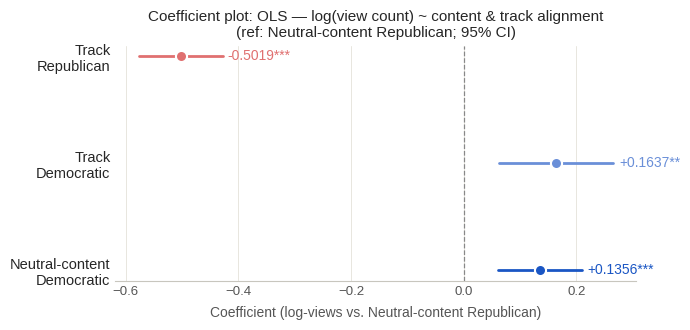

In [54]:

# ── Coefficient plot: log(views) ~ neutral-content Dem + track Dem + track Rep ──
# (Intercept omitted; reference = Neutral-content Republican)

_labels4 = {
    "is_neutral_content_democratic": "Neutral-content\nDemocratic",
    "is_track_democratic":           "Track\nDemocratic",
    "is_track_republican":           "Track\nRepublican",
}
_keys4   = list(_labels4.keys())
_names4  = [_labels4[k] for k in _keys4]
_coefs4  = [model4.params[k]  for k in _keys4]
_lo4     = [model4.conf_int().loc[k, 0] for k in _keys4]
_hi4     = [model4.conf_int().loc[k, 1] for k in _keys4]
_pvals4  = [model4.pvalues[k] for k in _keys4]

_colors4 = ["#1a56c4", "#6a8fd8", "#e07070"]
_y4      = range(len(_keys4))

fig, ax = plt.subplots(figsize=(7, 3.4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.axvline(0, color="#888", linewidth=0.9, linestyle="--", zorder=1)

for i, (coef, lo, hi, col, p) in enumerate(zip(_coefs4, _lo4, _hi4, _colors4, _pvals4)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=2, solid_capstyle="round", zorder=2)
    ax.plot(coef, i, "o", color=col, markersize=8, zorder=3,
            markeredgecolor="white", markeredgewidth=1.5)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else ""
    _span = max(abs(hi - lo), 0.01)
    ax.text(hi + _span * 0.06, i, f"{coef:+.4f}{sig}",
            va="center", ha="left", fontsize=10, color=col)

ax.set_yticks(list(_y4))
ax.set_yticklabels(_names4, fontsize=10.5)
ax.tick_params(axis="x", labelsize=9.5, colors="#555", length=0)
ax.tick_params(axis="y", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#c8c6be")
ax.spines["bottom"].set_linewidth(0.8)

ax.set_xlabel("Coefficient (log-views vs. Neutral-content Republican)", fontsize=10, color="#555", labelpad=6)
ax.set_title("Coefficient plot: OLS — log(view count) ~ content & track alignment\n(ref: Neutral-content Republican; 95% CI)", fontsize=11)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color="#e8e6de", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("output/figure10.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
